In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
df = pd.read_csv("Student_Performance.csv")

In [28]:
df.head(30)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,64
2,8,51,1,7,2,45
3,5,52,1,5,2,37
4,7,75,0,8,5,67
5,3,78,0,9,6,59
6,7,73,1,5,6,65
7,8,45,1,4,6,36
8,5,77,0,8,2,62
9,4,89,0,4,0,70


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [30]:
df.shape

(10000, 6)

In [31]:
print(df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


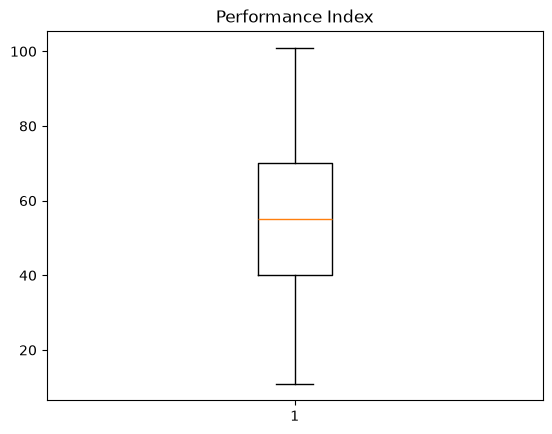

In [32]:
plt.boxplot(df["Performance Index"])
plt.title("Performance Index")
plt.show()

In [33]:
x = df.drop("Performance Index", axis = 1)
y = df["Performance Index"]

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

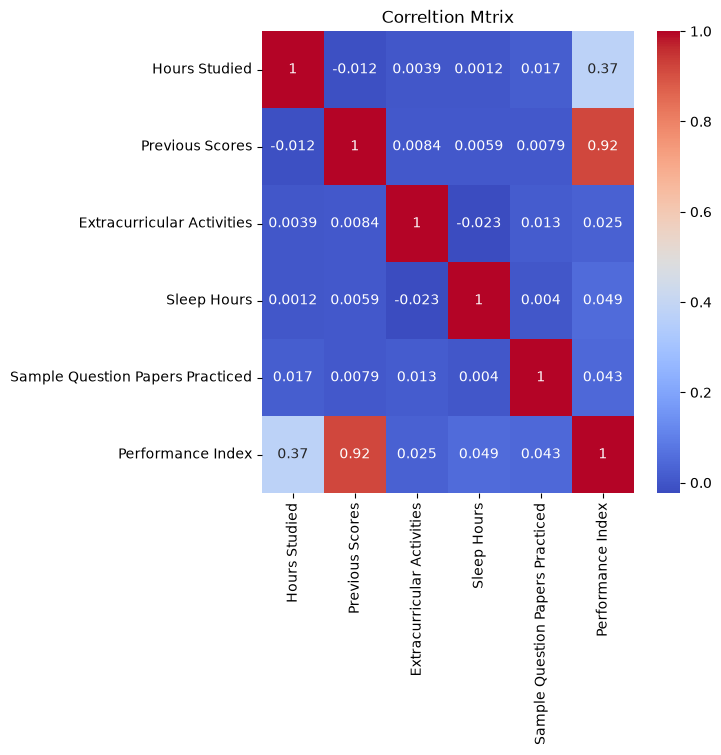

In [36]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correltion Mtrix")
plt.show()

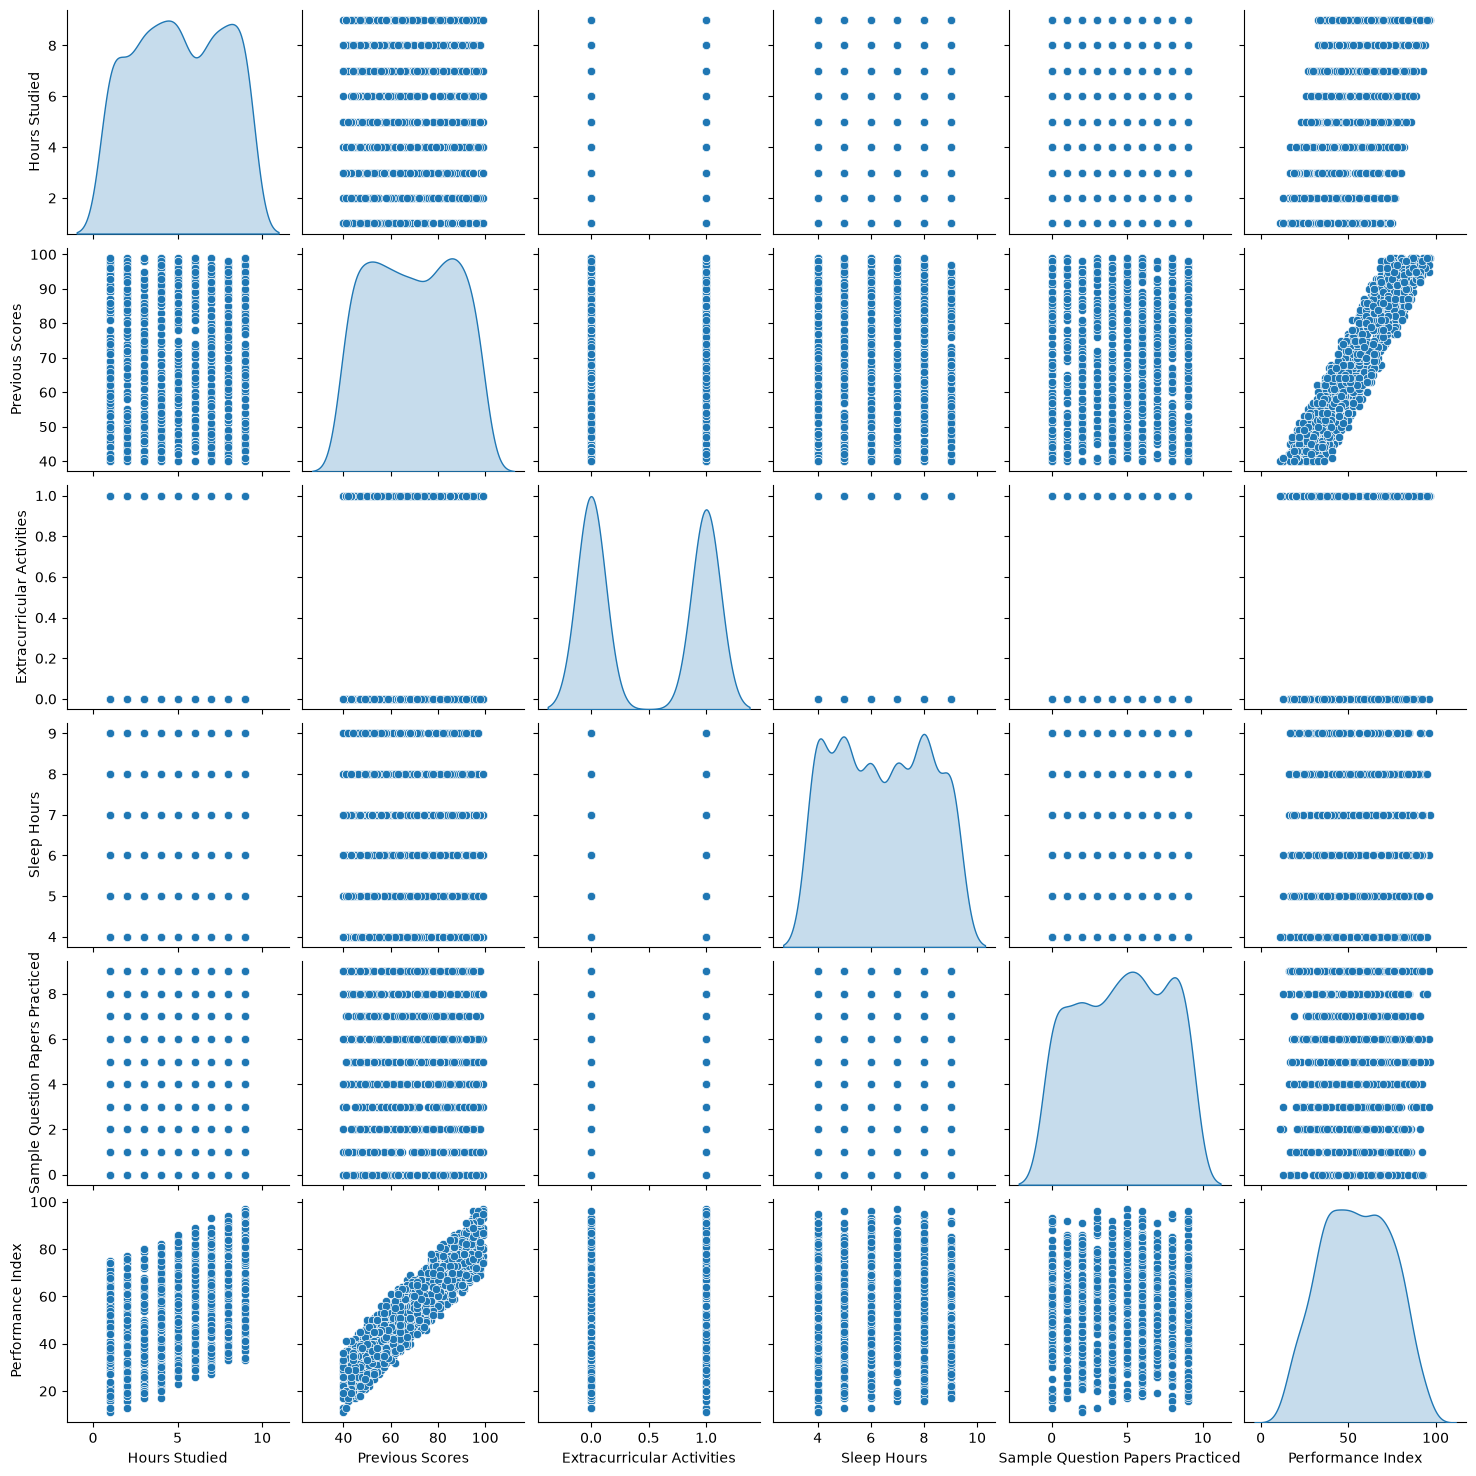

In [37]:
sns.pairplot(df.sample(1000), diag_kind="kde")
plt.show()

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 7.36,17.65, 0.32, 0.83, 0.55]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,54.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[90.49,90.1 ,89.83,88.71,88.2 ]"


In [39]:
y_pred = model.predict(X_test)
# y_pred = model.predict([[9, 98, 1, 7, 7]])
# print(y_pred)

In [40]:
def performace_index():
    print("\n Enter Student's Info To Get Score: ")

    hours = int(input("Hours Studied (1-9): "))
    pre_scr = int(input("Previous Scores (30-100): "))
    ex_ec = int(input("Extracurricular Activities (0- No, 1- Yes): "))
    slp_hr = int(input("Sleep Hours (0-9): "))
    qu_pp = int(input("Sample Question Papers Practiced (0-9): "))

    user_input = pd.DataFrame([[hours, pre_scr, ex_ec, slp_hr, qu_pp]], columns = x.columns)

    user_scaled = scaler.transform(user_input)

    pr_ind = model.predict(user_scaled)[0]

    print(f"\n Performance Index:  {pr_ind:,.0f}")

performace_index()


 Enter Student's Info To Get Score: 

 Performance Index:  70


In [41]:
# y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 2.431585326444537
R^2 Score: 0.9933685358322893


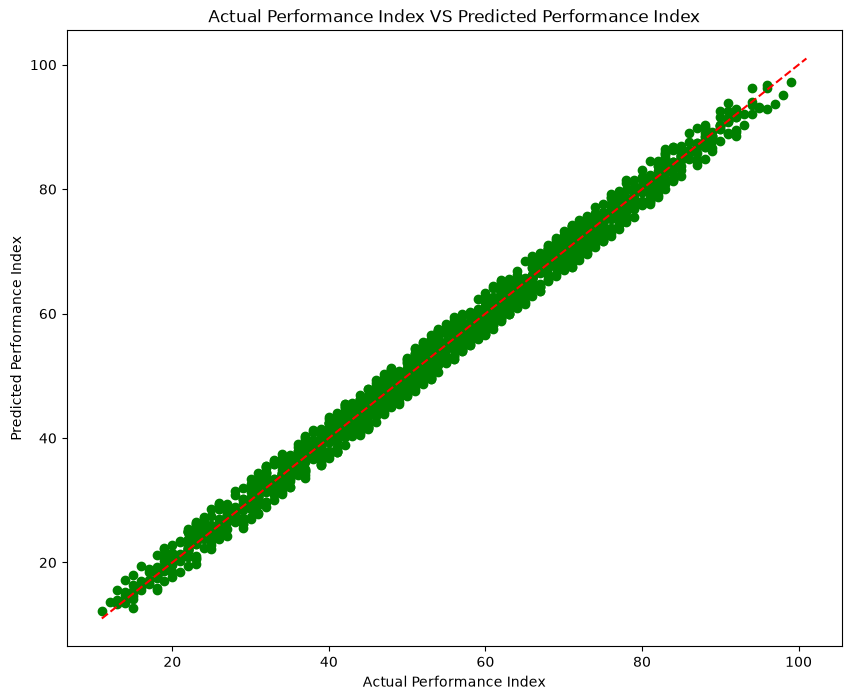

In [42]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, alpha = 1, color = "green")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual Performance Index VS Predicted Performance Index")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.show()